In [3]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Predict Apple Stock using LSTM

1. Load data

In [4]:
df = pd.read_csv("appl_1980_2014.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


In [5]:
#make sure your data is of actually date format
# df.info()
df.Date = pd.to_datetime(df.Date)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8465 entries, 0 to 8464
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       8465 non-null   datetime64[ns]
 1   Open       8465 non-null   float64       
 2   High       8465 non-null   float64       
 3   Low        8465 non-null   float64       
 4   Close      8465 non-null   float64       
 5   Volume     8465 non-null   int64         
 6   Adj Close  8465 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 463.1 KB


## Choose the timeframe

In [6]:
# df.Date.dt.year.unique()
cond = (df.Date.dt.year > 2009) & (df.Date.dt.year < 2014)
df = df[cond]
df.Date.dt.year.unique()

array([2013, 2012, 2011, 2010], dtype=int32)

## Set data as index

In [7]:
df = df.set_index('Date')
df.index

DatetimeIndex(['2013-12-31', '2013-12-30', '2013-12-27', '2013-12-26',
               '2013-12-24', '2013-12-23', '2013-12-20', '2013-12-19',
               '2013-12-18', '2013-12-17',
               ...
               '2010-01-15', '2010-01-14', '2010-01-13', '2010-01-12',
               '2010-01-11', '2010-01-08', '2010-01-07', '2010-01-06',
               '2010-01-05', '2010-01-04'],
              dtype='datetime64[ns]', name='Date', length=1006, freq=None)

In [8]:
df.sort_index(ascending=True, inplace=True)

In [9]:
df.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
2010-01-04,213.43,214.50,212.38,214.01,123432400,29.22
2010-01-05,214.60,215.59,213.25,214.38,150476200,29.27
2010-01-06,214.38,215.23,210.75,210.97,138040000,28.81
2010-01-07,211.75,212.00,209.05,210.58,119282800,28.75
2010-01-08,210.30,212.00,209.06,211.98,111902700,28.94


In [10]:
df.isnull().sum()

Open         0
High         0
Low          0
Close        0
Volume       0
Adj Close    0
dtype: int64

In [ ]:
#plot the apple stocks
plt.figure(figsize=(12, 4))
plt.title('Apple Stock Prices (2010 - 2013)')
plt.ylabel('Close')
plt.grid()
plt.plot(df.Close)

3. Train test Split

In [13]:
y = df['Close'].values.astype('float')
train_set = y[:-15]  #takes everything except the last 15 elements
test_set  = y[-15:]

In [14]:
type(train_set)

numpy.ndarray

### 4. Normalization

In [15]:
train_set.shape

(991,)

In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1,1))
train_set_norm = scaler.fit_transform(train_set.reshape(-1,1))

In [17]:
train_set_norm.min(), train_set_norm.max()

(np.float64(-0.9999999999999999), np.float64(1.0))

### Prepare Train set
Exercise 1: Window Size Experiment

Change ws = 30 to ws = 7, then ws = 60
Retrain the model for each window size
Plot and compare the predictions
Which window size works best? Why?
What happens when window is too small or too large?

In [18]:
#convert np to tensor
train_set_norm = torch.FloatTensor(train_set_norm).view(-1)
train_set_norm.shape

#define window size
ws = 7 #use 7 days in the past to predict the next day

#define function to create training set (ws days -> 1 day)
#sample 0:  Day 1 to Day 30 -> Day 31
#sample 1:  Day 2 to Day 31 -> Day 32
#...
def create_data(seq, label):
    out = []
    #array to hold the out
    #i runs from 0 to (991 - 30)
    for i in range(seq.shape[0] - label):
        x = seq[i:i+label]          # 30 days in the past
        y = seq[i+label:i+label+1]  # next day
        out.append((x, y))
    return out

nabin_data = create_data(train_set_norm, ws)

In [19]:
nabin_data[0]

(tensor([-0.9139, -0.9124, -0.9258, -0.9273, -0.9219, -0.9292, -0.9386]),
 tensor([-0.9271]))

In [20]:
len(nabin_data)

984

### Neural Network

In [21]:
sample, target = nabin_data[0]

In [23]:
sample.shape  #7 samples in a time series

torch.Size([7])

In [25]:
target.shape #this is the th n8umber after the 7 samples

torch.Size([1])

In [26]:
sample_reshape = sample.reshape(sample.shape[0], 1, -1)  #(1, 7)

In [27]:
lstm = nn.LSTM(1, 50)

In [28]:
out, hidden = lstm(sample_reshape)  #hidden has both h and c

In [29]:
out.shape #(length, batch size, hidden size)

torch.Size([7, 1, 50])

In [30]:
hidden[0].shape #(num layer, batch size, hidden size)

torch.Size([1, 1, 50])

In [31]:
out = out.view(len(out), -1)
out.shape

torch.Size([7, 50])

In [32]:
linear_layer = nn.Linear(50, 1)

In [33]:
out = linear_layer(out)
out.shape

torch.Size([7, 1])

### Network

In [34]:
class chaky_RNN(nn.Module):
    def __init__(self, input_s = 1, hs = 50, output_size = 1):
        super().__init__()
        self.hs = hs
        self.lstm = nn.LSTM(input_s, hs)  #LSTM will automatically create W(s) for us
        self.linear = nn.Linear(hs, output_size)  #take output of LSTM, project to prediction
        
    def forward(self, input_):
        out, _ = self.lstm(input_.reshape(input_.shape[0], 1, -1)) #30, 1, 1
        out    = self.linear(out.view(len(input_), -1))  #30, 50
        return out[-1]

In [35]:
torch.manual_seed(999)
model = NABIN_RNN()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [36]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')
    
count_parameters(model)

   200
 10000
   200
   200
    50
     1
______
 10651


### 7. Training

In [37]:
epochs = 100

for i in range(epochs):
    
    # tuple-unpack the chaky_data set
    for seq, y_train in nabin_data:  
        y_pred = model(seq)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # print training result
    if i % 10 == 0:
        print(f'Epoch: {i:2} Loss: {loss.item():10.8f}')

Epoch:  0 Loss: 0.00856967
Epoch: 10 Loss: 0.00396998
Epoch: 20 Loss: 0.00351243
Epoch: 30 Loss: 0.00331849
Epoch: 40 Loss: 0.00314079
Epoch: 50 Loss: 0.00288611
Epoch: 60 Loss: 0.00261570
Epoch: 70 Loss: 0.00237771
Epoch: 80 Loss: 0.00225022
Epoch: 90 Loss: 0.00219566


### 8. Testing

In [38]:
# Prediction 1:
# seq = [Day 961, ..., Day 990]  # Last 30 from preds
# yhat = model(seq)  # Predicts Day 991
# preds.append(Day 991)  # Now preds has 31 values

# # Prediction 2:
# seq = [Day 962, ..., Day 991]  # Last 30 from preds (notice Day 961 dropped)
# yhat = model(seq)  # Predicts Day 992
# preds.append(Day 992)  # Now preds has 32 values

# # Prediction 3:
# seq = [Day 963, ..., Day 992]  # Last 30 from preds
# yhat = model(seq)  # Predicts Day 993
# preds.append(Day 993)

# # ... continues for 30 iterations

preds = train_set_norm[-ws:].tolist()  #start with last 30 days of training,  this is the input to predict the test set

model.eval()

for i in range(15): #we want to predict 15 days
    seq = torch.FloatTensor(preds[-ws:])  #the reason is because we keep appending on this, until we get 15 predictions, then compare to test set
    with torch.no_grad():
        yhat = model(seq)
        preds.append(yhat.item())

### 9. Plotting

In [39]:
np.array(preds[-ws:]).reshape(-1, 1).shape

(7, 1)

In [40]:
#1. inverse the normalization
true_numbers = scaler.inverse_transform(np.array(preds[-ws:]).reshape(-1, 1))

In [41]:

#2. plot
x = df['Close'][-ws:].index

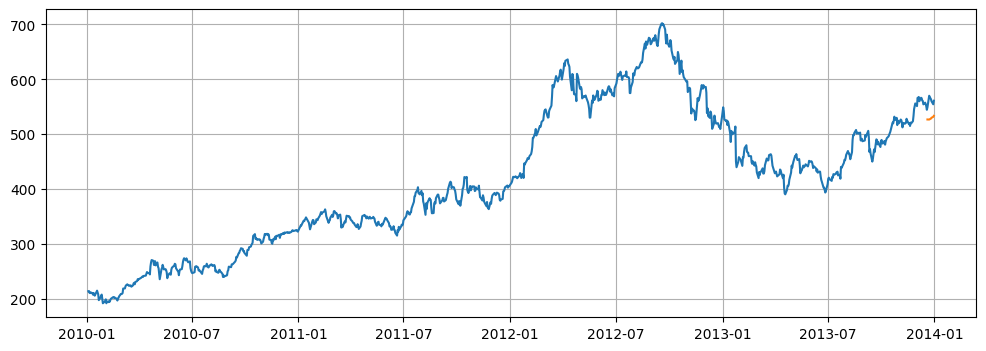

In [42]:

plt.figure(figsize=(12, 4))
plt.grid()
plt.plot(df['Close'])  #historical data
plt.plot(x, true_numbers)

### Prepare Train set
Now changing  ws = 60



In [44]:
#convert np to tensor
train_set_norm = torch.FloatTensor(train_set_norm).view(-1)
train_set_norm.shape

#define window size
ws = 60 #use 7 days in the past to predict the next day

#define function to create training set (ws days -> 1 day)
#sample 0:  Day 1 to Day 30 -> Day 31
#sample 1:  Day 2 to Day 31 -> Day 32
#...
def create_data(seq, label):
    out = []
    #array to hold the out
    #i runs from 0 to (991 - 30)
    for i in range(seq.shape[0] - label):
        x = seq[i:i+label]          # 30 days in the past
        y = seq[i+label:i+label+1]  # next day
        out.append((x, y))
    return out

nabin_data = create_data(train_set_norm, ws)

In [45]:
nabin_data[0]

(tensor([-0.9139, -0.9124, -0.9258, -0.9273, -0.9219, -0.9292, -0.9386, -0.9271,
         -0.9318, -0.9456, -0.9099, -0.9228, -0.9372, -0.9776, -0.9568, -0.9455,
         -0.9379, -0.9716, -1.0000, -0.9895, -0.9851, -0.9718, -1.0000, -0.9866,
         -0.9919, -0.9838, -0.9880, -0.9740, -0.9673, -0.9555, -0.9588, -0.9573,
         -0.9623, -0.9672, -0.9804, -0.9662, -0.9610, -0.9507, -0.9336, -0.9341,
         -0.9322, -0.9268, -0.8945, -0.8940, -0.8786, -0.8714, -0.8688, -0.8645,
         -0.8753, -0.8730, -0.8742, -0.8722, -0.8816, -0.8718, -0.8576, -0.8537,
         -0.8643, -0.8477, -0.8418, -0.8283]),
 tensor([-0.8316]))

In [46]:

len(nabin_data) # 991 - 30 = 961 --> Total days - window size = number of samples

931

### Neural Network

In [47]:
sample, target = nabin_data[0]

In [48]:
sample.shape  #30 samples in a time series

torch.Size([60])

In [49]:
target.shape #this is the 31th number after the 30 samples

torch.Size([1])

In [50]:
sample_reshape = sample.reshape(sample.shape[0], 1, -1)  #(1, 30)

In [51]:
lstm = nn.LSTM(1, 50)

In [52]:
out, hidden = lstm(sample_reshape)  #hidden has both h and c

In [53]:
out.shape #(length, batch size, hidden size)

torch.Size([60, 1, 50])

In [54]:
hidden[0].shape #(num layer, batch size, hidden size)

torch.Size([1, 1, 50])

In [55]:
# assert out[-1] == hidden[0]

In [56]:
out = out.view(len(out), -1)
out.shape

torch.Size([60, 50])

In [57]:
linear_layer = nn.Linear(50, 1)

In [58]:
out = linear_layer(out)
out.shape

torch.Size([60, 1])

### Network

In [59]:
class NABIN_RNN(nn.Module):
    def __init__(self, input_s = 1, hs = 50, output_size = 1):
        super().__init__()
        self.hs = hs
        self.lstm = nn.LSTM(input_s, hs)  #LSTM will automatically create W(s) for us
        self.linear = nn.Linear(hs, output_size)  #take output of LSTM, project to prediction
        
    def forward(self, input_):
        out, _ = self.lstm(input_.reshape(input_.shape[0], 1, -1)) #30, 1, 1
        out    = self.linear(out.view(len(input_), -1))  #30, 50
        return out[-1]

In [60]:
torch.manual_seed(999)
model = NABIN_RNN()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [61]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')
    
count_parameters(model)

   200
 10000
   200
   200
    50
     1
______
 10651


### 7. Training

In [62]:
epochs = 100

for i in range(epochs):
    
    # tuple-unpack the chaky_data set
    for seq, y_train in chaky_data:  
        y_pred = model(seq)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # print training result
    if i % 10 == 0:
        print(f'Epoch: {i:2} Loss: {loss.item():10.8f}')

Epoch:  0 Loss: 0.01212254
Epoch: 10 Loss: 0.00290910
Epoch: 20 Loss: 0.00484314
Epoch: 30 Loss: 0.00234827
Epoch: 40 Loss: 0.00210144
Epoch: 50 Loss: 0.00104933
Epoch: 60 Loss: 0.00018106
Epoch: 70 Loss: 0.00149900
Epoch: 80 Loss: 0.00184395
Epoch: 90 Loss: 0.00134361


#### 8. Testing

In [65]:
preds = train_set_norm[-ws:].tolist()  #start with last 30 days of training,  this is the input to predict the test set

model.eval()

for i in range(15): #we want to predict 15 days
    seq = torch.FloatTensor(preds[-ws:])  #the reason is because we keep appending on this, until we get 15 predictions, then compare to test set
    with torch.no_grad():
        yhat = model(seq)

### 9. Plotting

In [66]:
np.array(preds[-ws:]).reshape(-1, 1).shape

(60, 1)

In [67]:
#1. inverse the normalization
true_numbers = scaler.inverse_transform(np.array(preds[-ws:]).reshape(-1, 1))

In [68]:
#2. plot
x = df['Close'][-ws:].index

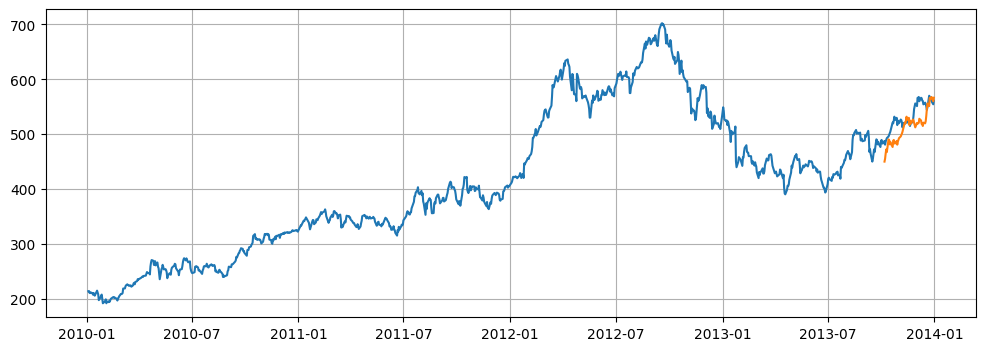

In [69]:
plt.figure(figsize=(12, 4))
plt.grid()
plt.plot(df['Close'])  #historical data
plt.plot(x, true_numbers)

### The window size of 60 works best.
It produces smoother and more realistic predictions that closely follow the overall trend of the stock prices. A larger window allows the RNN to learn long-term dependencies and patterns in the data, which helps in reducing noise and making more stable forecasts. In contrast, a smaller window (like 7) reacts too quickly to short-term fluctuations, leading to more noisy and less generalizable predictions.

### What happens when the window is too small or too large?

When the window is too small:
The model only looks at a short history of data, so it may miss important long-term trends. This causes the predictions to become unstable, noisy, and prone to overfitting recent changes.

When the window is too large:
The model includes too much past data, which can make it slower to react to recent changes. Training also becomes computationally expensive, and sometimes the model may learn unnecessary or irrelevant information from the distant past.

### Exercise 2: Data Leakage - The Wrong Way

Replace the normalization code with this WRONG version:
   WRONG - fits scaler on ALL data (including test)
- y_all = df['Close'].values.astype('float')
- scaler = MinMaxScaler(feature_range=(-1, 1))
- y_all_norm = scaler.fit_transform(y_all.reshape(-1, 1)) 
- train_set_norm = y_all_norm[:-15]

In [70]:
y_all = df['Close'].values.astype('float')
train_set = y_all[:-15]  #takes everything except the last 15 elements
test_set  = y_all[-15:]

Normalization

In [73]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

y_all_norm = scaler.fit_transform(y_all.reshape(-1, 1))
train_set_norm = y_all_norm[:-15]



In [74]:
train_set_norm.min(), train_set_norm.max()

(np.float64(-0.9999999999999999), np.float64(1.0))

Prepare train set

In [75]:
#convert np to tensor
train_set_norm = torch.FloatTensor(train_set_norm).view(-1)
train_set_norm.shape

#define window size
ws = 7 #use 30 days in the past to predict the next day

#define function to create training set (ws days -> 1 day)
#sample 0:  Day 1 to Day 30 -> Day 31
#sample 1:  Day 2 to Day 31 -> Day 32
#...
def create_data(seq, label):
    out = []
    #array to hold the out
    #i runs from 0 to (991 - 30)
    for i in range(seq.shape[0] - label):
        x = seq[i:i+label]          # 30 days in the past
        y = seq[i+label:i+label+1]  # next day
        out.append((x, y))
    return out

chaky_data = create_data(train_set_norm, ws)

In [76]:

chaky_data[0]

(tensor([-0.9139, -0.9124, -0.9258, -0.9273, -0.9219, -0.9292, -0.9386]),
 tensor([-0.9271]))

In [77]:
len(chaky_data) # 991 - 30 = 961 --> Total days - window size = number of samples

984

Neural Network

In [78]:
class NABIN_RNN(nn.Module):
    def __init__(self, input_s = 1, hs = 50, output_size = 1):
        super().__init__()
        self.hs = hs
        self.lstm = nn.LSTM(input_s, hs)  #LSTM will automatically create W(s) for us
        self.linear = nn.Linear(hs, output_size)  #take output of LSTM, project to prediction
        
    def forward(self, input_):
        out, _ = self.lstm(input_.reshape(input_.shape[0], 1, -1)) #30, 1, 1
        out    = self.linear(out.view(len(input_), -1))  #30, 50
        return out[-1]

In [79]:
torch.manual_seed(999)
model = NABIN_RNN()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [80]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')
    
count_parameters(model)

   200
 10000
   200
   200
    50
     1
______
 10651


Training

In [81]:
epochs = 100

for i in range(epochs):
    
    # tuple-unpack the chaky_data set
    for seq, y_train in chaky_data:  
        y_pred = model(seq)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # print training result
    if i % 10 == 0:
        print(f'Epoch: {i:2} Loss: {loss.item():10.8f}')

Epoch:  0 Loss: 0.00856967
Epoch: 10 Loss: 0.00396998
Epoch: 20 Loss: 0.00351243
Epoch: 30 Loss: 0.00331849
Epoch: 40 Loss: 0.00314079
Epoch: 50 Loss: 0.00288611
Epoch: 60 Loss: 0.00261570
Epoch: 70 Loss: 0.00237771
Epoch: 80 Loss: 0.00225022
Epoch: 90 Loss: 0.00219566


Testing

In [87]:
preds = train_set_norm[-ws:].tolist()  #start with last 30 days of training,  this is the input to predict the test set

model.eval()

for i in range(15): #we want to predict 15 days
    seq = torch.FloatTensor(preds[-ws:])  #the reason is because we keep appending on this, until we get 15 predictions, then compare to test set
    with torch.no_grad():
        yhat = model(seq)
        preds.append(yhat.item())

 Plotting

In [88]:
np.array(preds[-ws:]).reshape(-1, 1).shape
#1. inverse the normalization
true_numbers = scaler.inverse_transform(np.array(preds[-ws:]).reshape(-1, 1))

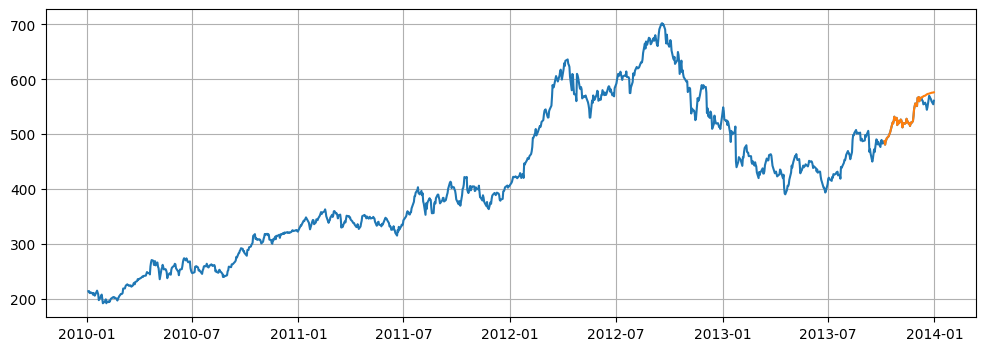

In [89]:
#2. plot
x = df['Close'][-ws:].index
plt.figure(figsize=(12, 4))
plt.grid()
plt.plot(df['Close'])  #historical data
plt.plot(x, true_numbers)

### again for 60 days

In [90]:
#convert np to tensor
train_set_norm = torch.FloatTensor(train_set_norm).view(-1)
train_set_norm.shape

#define window size
ws = 60 #use 30 days in the past to predict the next day

#define function to create training set (ws days -> 1 day)
#sample 0:  Day 1 to Day 30 -> Day 31
#sample 1:  Day 2 to Day 31 -> Day 32
#...
def create_data(seq, label):
    out = []
    #array to hold the out
    #i runs from 0 to (991 - 30)
    for i in range(seq.shape[0] - label):
        x = seq[i:i+label]          # 30 days in the past
        y = seq[i+label:i+label+1]  # next day
        out.append((x, y))
    return out

chaky_data = create_data(train_set_norm, ws)

In [91]:
epochs = 100

for i in range(epochs):
    
    # tuple-unpack the chaky_data set
    for seq, y_train in chaky_data:  
        y_pred = model(seq)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # print training result
    if i % 10 == 0:
        print(f'Epoch: {i:2} Loss: {loss.item():10.8f}')

Epoch:  0 Loss: 0.00226153
Epoch: 10 Loss: 0.00012918
Epoch: 20 Loss: 0.00017385
Epoch: 30 Loss: 0.00000834
Epoch: 40 Loss: 0.00086298
Epoch: 50 Loss: 0.00067945
Epoch: 60 Loss: 0.00010621
Epoch: 70 Loss: 0.00047221
Epoch: 80 Loss: 0.00044041
Epoch: 90 Loss: 0.00023820


In [98]:
preds = train_set_norm[-ws:].tolist()  #start with last 30 days of training,  this is the input to predict the test set

model.eval()

for i in range(15): #we want to predict 15 days
    seq = torch.FloatTensor(preds[-ws:])  #the reason is because we keep appending on this, until we get 15 predictions, then compare to test set
    with torch.no_grad():
        yhat = model(seq)
        preds.append(yhat.item())

In [99]:
np.array(preds[-ws:]).reshape(-1, 1).shape
#1. inverse the normalization
true_numbers = scaler.inverse_transform(np.array(preds[-ws:]).reshape(-1, 1))

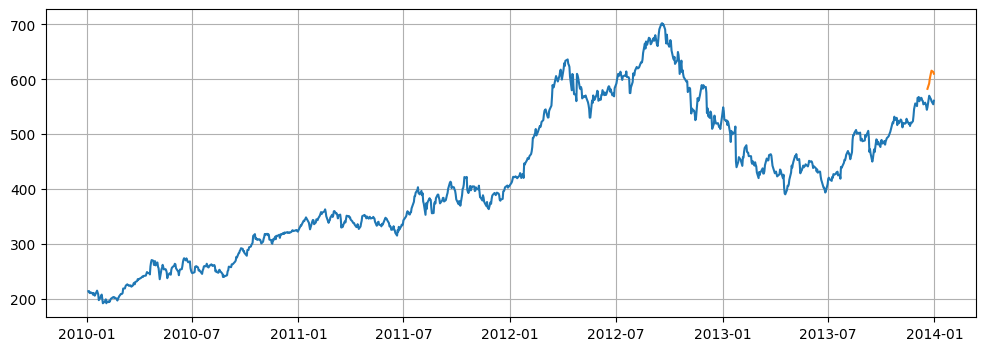

In [100]:
#2. plot
x = df['Close'][-ws:].index
plt.figure(figsize=(12, 4))
plt.grid()
plt.plot(df['Close'])  #historical data
plt.plot(x, true_numbers)

### Does it perform better or worse?
It performed better.
### Why is this result misleading and dangerous in real life?
This result is misleading because of data leakage. By fitting the scaler on all data (including the test set), information from the future leaks into the training process. This gives the model an unfair advantage — it indirectly "knows" the scale of unseen data.

Exercise 3: Predicting Far into the Future

- Change test size from 15 to 30, then to 60:
   - train_set = y[:-30]  # Try -30, then -60
   - test_set = y[-30:]   # Match the split
- Update prediction loop:
   for i in range(30):  # Match your test size
- Plot predictions for each test size
- Does accuracy get worse when predicting further ahead?
- Why does this happen? (Think about errors building up)

Train test split

In [101]:
y = df['Close'].values.astype('float')
train_set = y[:-30]  #takes everything except the last 15 elements
test_set  = y[-30:]

 Normalization

In [102]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

train_set_norm = scaler.fit_transform(train_set.reshape(-1, 1))

Prepare train set

In [118]:
#convert np to tensor
train_set_norm = torch.FloatTensor(train_set_norm).view(-1)
train_set_norm.shape

#define window size
ws = 7 #use 30 days in the past to predict the next day

#define function to create training set (ws days -> 1 day)
#sample 0:  Day 1 to Day 30 -> Day 31
#sample 1:  Day 2 to Day 31 -> Day 32
#...
def create_data(seq, label):
    out = []
    #array to hold the out
    #i runs from 0 to (991 - 30)
    for i in range(seq.shape[0] - label):
        x = seq[i:i+label]          # 30 days in the past
        y = seq[i+label:i+label+1]  # next day
        out.append((x, y))
    return out

chaky_data = create_data(train_set_norm, ws)

Neural Network

Training

In [105]:

epochs = 30

for i in range(epochs):
    
    # tuple-unpack the chaky_data set
    for seq, y_train in chaky_data:  
        y_pred = model(seq)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # print training result
    if i % 10 == 0:
        print(f'Epoch: {i:2} Loss: {loss.item():10.8f}')

Epoch:  0 Loss: 0.00022970
Epoch: 10 Loss: 0.00016270
Epoch: 20 Loss: 0.00004147


Testing

In [ ]:
preds = train_set_norm[-ws:].tolist()  #start with last 30 days of training,  this is the input to predict the test set

model.eval()

for i in range(30): #we want to predict 15 days
    seq = torch.FloatTensor(preds[-ws:])  #the reason is because we keep appending on this, until we get 15 predictions, then compare to test set
    with torch.no_grad():
        yhat = model(seq)
        preds.append(yhat.item())

Plotting

In [ ]:
np.array(preds[-ws:]).reshape(-1, 1).shape
#1. inverse the normalization
true_numbers = scaler.inverse_transform(np.array(preds[-ws:]).reshape(-1, 1))
#2. plot
x = df['Close'][-ws:].index
plt.figure(figsize=(12, 4))
plt.grid()
plt.plot(df['Close'])  #historical data
plt.plot(x, true_numbers)

Again Assiging test size 60

In [ ]:
y = df['Close'].values.astype('float')
train_set = y[:-60]  #takes everything except the last 15 elements
test_set  = y[-60:]

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

train_set_norm = scaler.fit_transform(train_set.reshape(-1, 1))

In [ ]:
#convert np to tensor
train_set_norm = torch.FloatTensor(train_set_norm).view(-1)
train_set_norm.shape

#define window size
ws = 7 #use 30 days in the past to predict the next day

#define function to create training set (ws days -> 1 day)
#sample 0:  Day 1 to Day 30 -> Day 31
#sample 1:  Day 2 to Day 31 -> Day 32
#...
def create_data(seq, label):
    out = []
    #array to hold the out
    #i runs from 0 to (991 - 30)
    for i in range(seq.shape[0] - label):
        x = seq[i:i+label]          # 30 days in the past
        y = seq[i+label:i+label+1]  # next day
        out.append((x, y))
    return out

chaky_data = create_data(train_set_norm, ws)

In [120]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
epochs = 30

for i in range(epochs):
    
    # tuple-unpack the chaky_data set
    for seq, y_train in chaky_data:  
        y_pred = model(seq)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # print training result
    if i % 10 == 0:
        print(f'Epoch: {i:2} Loss: {loss.item():10.8f}')

Using device: cuda
Epoch:  0 Loss: 0.00033621
Epoch: 10 Loss: 0.00037117
Epoch: 20 Loss: 0.00037254


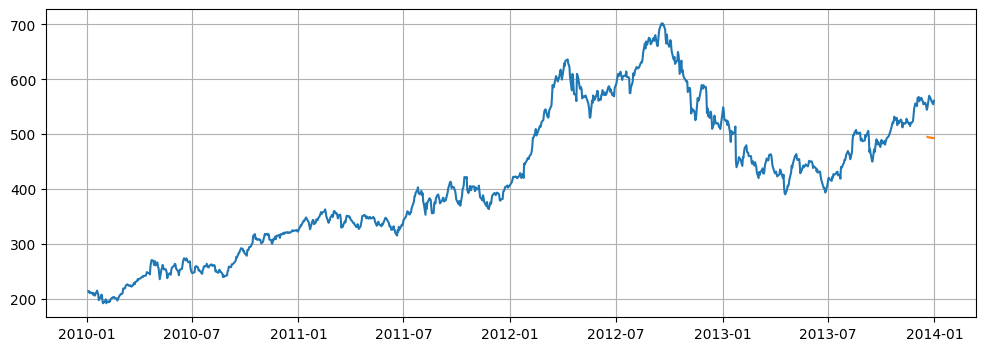

In [121]:
preds = train_set_norm[-ws:].tolist()  #start with last 30 days of training,  this is the input to predict the test set

model.eval()

for i in range(30): #we want to predict 15 days
    seq = torch.FloatTensor(preds[-ws:])  #the reason is because we keep appending on this, until we get 15 predictions, then compare to test set
    with torch.no_grad():
        yhat = model(seq)
        preds.append(yhat.item())

np.array(preds[-ws:]).reshape(-1, 1).shape
#1. inverse the normalization
true_numbers = scaler.inverse_transform(np.array(preds[-ws:]).reshape(-1, 1))
#2. plot
x = df['Close'][-ws:].index
plt.figure(figsize=(12, 4))
plt.grid()
plt.plot(df['Close'])  #historical data
plt.plot(x, true_numbers)

Using device: cuda
Epoch:  0 Loss: 0.00020786
Epoch: 10 Loss: 0.00000024
Epoch: 20 Loss: 0.00001151
Epoch: 30 Loss: 0.00003887
Epoch: 40 Loss: 0.00274919
Epoch: 50 Loss: 0.00093487
Epoch: 60 Loss: 0.00074593
Epoch: 70 Loss: 0.00117160
Epoch: 80 Loss: 0.00327850
Epoch: 90 Loss: 0.00827601


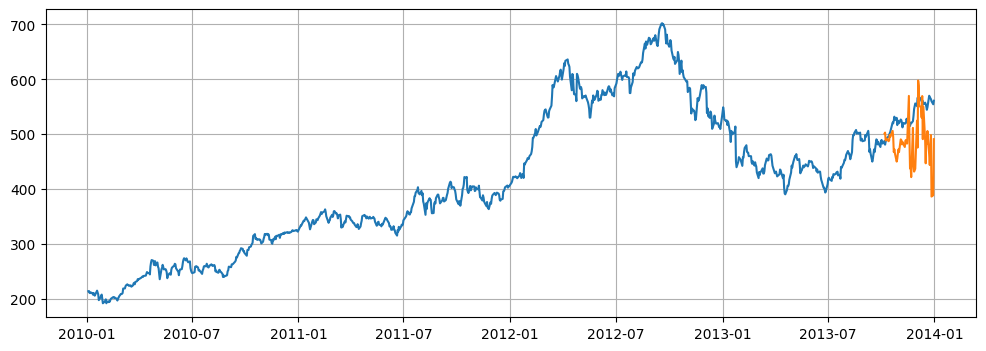

In [122]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
y = df['Close'].values.astype('float')
train_set = y[:-60]  #takes everything except the last 15 elements
test_set  = y[-60:]
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

train_set_norm = scaler.fit_transform(train_set.reshape(-1, 1))

#convert np to tensor
train_set_norm = torch.FloatTensor(train_set_norm).view(-1)
train_set_norm.shape

#define window size
ws = 60 #use 30 days in the past to predict the next day

#define function to create training set (ws days -> 1 day)
#sample 0:  Day 1 to Day 30 -> Day 31
#sample 1:  Day 2 to Day 31 -> Day 32
#...
def create_data(seq, label):
    out = []
    #array to hold the out
    #i runs from 0 to (991 - 30)
    for i in range(seq.shape[0] - label):
        x = seq[i:i+label]          # 30 days in the past
        y = seq[i+label:i+label+1]  # next day
        out.append((x, y))
    return out

chaky_data = create_data(train_set_norm, ws)

epochs = 100

for i in range(epochs):
    
    # tuple-unpack the chaky_data set
    for seq, y_train in chaky_data:  
        y_pred = model(seq)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # print training result
    if i % 10 == 0:
        print(f'Epoch: {i:2} Loss: {loss.item():10.8f}')


preds = train_set_norm[-ws:].tolist()  #start with last 30 days of training,  this is the input to predict the test set

model.eval()

for i in range(30): #we want to predict 15 days
    seq = torch.FloatTensor(preds[-ws:])  #the reason is because we keep appending on this, until we get 15 predictions, then compare to test set
    with torch.no_grad():
        yhat = model(seq)
        preds.append(yhat.item())

np.array(preds[-ws:]).reshape(-1, 1).shape
#1. inverse the normalization
true_numbers = scaler.inverse_transform(np.array(preds[-ws:]).reshape(-1, 1))
#2. plot
x = df['Close'][-ws:].index
plt.figure(figsize=(12, 4))
plt.grid()
plt.plot(df['Close'])  #historical data
plt.plot(x, true_numbers)

### Does accuracy get worse when predicting further ahead?
- Yes. When you increase the test horizon (15 → 30 → 60), multi-step forecasts become less accurate on average.

### Why does this happen?
- Error compounding: Each step uses the previous prediction as input; small errors snowball over many steps.
- Information decay: Distant future points depend less on recent history your model sees, so signal weakens.
- Non-stationarity & noise: Stock series shift (regimes, news, volatility), so patterns learned on the past fit the near term better than far ahead.
- Exposure bias: Trained on true past values (teacher forcing) but must infer from its own predictions at test time, amplifying drift.

Exercise 4: Model Size Matters

- Try different hidden sizes:
   - model = chaky_RNN(input_s=1, hs=10, output_size=1)   # Small
   - model = chaky_RNN(input_s=1, hs=100, output_size=1)  # Large
- Use count_parameters(model) to see parameter count
- Train and compare results
- Does bigger always mean better?
- What are the trade-offs?


=== Training LSTM with hidden size = 10 ===
      40
     400
      40
      40
      10
       1
________
Total:      531
Epoch:   0  Loss: 0.00006962
Epoch:  10  Loss: 0.00012258
Epoch:  20  Loss: 0.00001194

=== Training LSTM with hidden size = 100 ===
     400
   40000
     400
     400
     100
       1
________
Total:    41301
Epoch:   0  Loss: 0.00000690
Epoch:  10  Loss: 0.00001871
Epoch:  20  Loss: 0.00000564


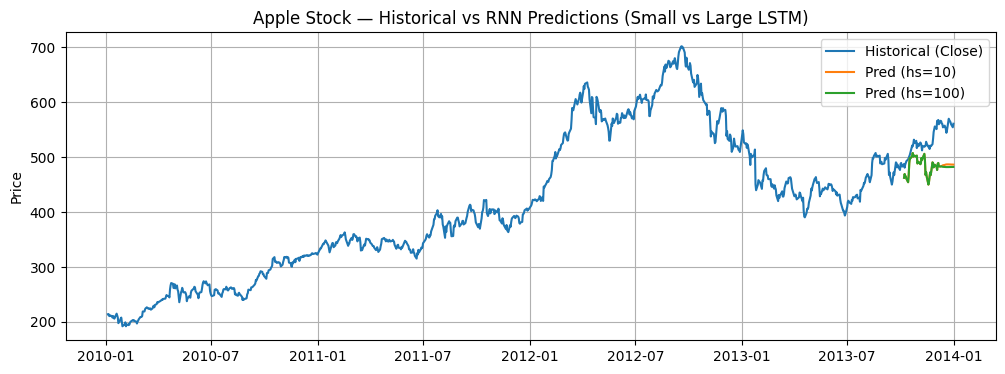

In [132]:
# --- Exercise 4: Model Size Matters (Small vs Large LSTM) ---

torch.manual_seed(999)

# --- Model Definition ---
class NABIN_RNN(nn.Module):
    def __init__(self, input_s=1, hs=50, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_s, hs)
        self.linear = nn.Linear(hs, output_size)

    def forward(self, input_):
        x = input_.reshape(len(input_), 1, -1)
        out, _ = self.lstm(x)
        out = self.linear(out.view(len(input_), -1))
        return out[-1]

# --- Function to Count Parameters ---
def count_parameters(model, verbose=True):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    if verbose:
        for item in params:
            print(f'{item:>8}')
        print(f'________\nTotal: {sum(params):>8}')
    return sum(params)

# --- Training Function ---
def train_one_model(hs, chaky_data, epochs=100, lr=0.001, device='cpu'):
    model = NABIN_RNN(input_s=1, hs=hs, output_size=1).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    print(f"\n=== Training LSTM with hidden size = {hs} ===")
    total_params = count_parameters(model, verbose=True)

    for i in range(30):
        for seq, y_train in chaky_data:
            seq = seq.to(device)
            y_train = y_train.to(device)

            y_pred = model(seq)
            loss = criterion(y_pred, y_train)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if i % 10 == 0:
            print(f'Epoch: {i:3d}  Loss: {loss.item():.8f}')

    return model, total_params, loss.item()

# --- Prediction Function ---
def predict_next_n(model, preds_seed_list, n_steps, ws, device='cpu'):
    preds = preds_seed_list[:]
    model.eval()
    with torch.no_grad():
        for _ in range(n_steps):
            seq = torch.FloatTensor(preds[-ws:]).to(device)
            yhat = model(seq)
            preds.append(yhat.item())
    return preds

# --- Experiment Setup ---
small_hs = 10
large_hs = 100
epochs = 100
future_days = 15
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# You must already have these defined earlier:
# ws, chaky_data, scaler, train_set_norm, df

# --- Train Small and Large Models ---
small_model, small_params, small_loss = train_one_model(
    hs=small_hs, chaky_data=chaky_data, epochs=epochs, device=device
)
large_model, large_params, large_loss = train_one_model(
    hs=large_hs, chaky_data=chaky_data, epochs=epochs, device=device
)

# --- Predict Using Both Models ---
seed_list = train_set_norm[-ws:].tolist()
small_preds = predict_next_n(small_model, seed_list, future_days, ws, device)
large_preds = predict_next_n(large_model, seed_list, future_days, ws, device)

small_tail = np.array(small_preds[-ws:]).reshape(-1, 1)
large_tail = np.array(large_preds[-ws:]).reshape(-1, 1)

small_true = scaler.inverse_transform(small_tail).ravel()
large_true = scaler.inverse_transform(large_tail).ravel()

x_future = df['Close'][-ws:].index

# --- Plot Historical vs Predictions ---
plt.figure(figsize=(12, 4))
plt.grid(True)
plt.plot(df['Close'], label='Historical (Close)')
plt.plot(x_future, small_true, label=f'Pred (hs={small_hs})')
plt.plot(x_future, large_true, label=f'Pred (hs={large_hs})')
plt.title('Apple Stock — Historical vs RNN Predictions (Small vs Large LSTM)')
plt.ylabel('Price')
plt.legend()
plt.show()



In [133]:
# --- Comparison Summary ---
print("\n=== Comparison Summary ===")
print(f"Small LSTM (hs={small_hs}) -> params: {small_params:,} | final training loss: {small_loss:.6f}")
print(f"Large LSTM (hs={large_hs}) -> params: {large_params:,} | final training loss: {large_loss:.6f}")
print("\nDoes bigger always mean better?")
print("- Larger hidden size may reduce training loss but can overfit and slow training.")
print("- Smaller hidden size generalizes better on limited data but may underfit.")
print("Trade-offs: accuracy vs. overfitting, training time, and memory usage.")


=== Comparison Summary ===
Small LSTM (hs=10) -> params: 531 | final training loss: 0.000001
Large LSTM (hs=100) -> params: 41,301 | final training loss: 0.000002

Does bigger always mean better?
- Larger hidden size may reduce training loss but can overfit and slow training.
- Smaller hidden size generalizes better on limited data but may underfit.
Trade-offs: accuracy vs. overfitting, training time, and memory usage.


In [ ]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


class NABIN_RNN(nn.Module):
    def __init__(self, input_s = 1, hs = 10, output_size = 1):
        super().__init__()
        self.hs = hs
        self.lstm = nn.LSTM(input_s, hs)  #LSTM will automatically create W(s) for us
        self.linear = nn.Linear(hs, output_size)  #take output of LSTM, project to prediction
        
    def forward(self, input_):
        out, _ = self.lstm(input_.reshape(input_.shape[0], 1, -1)) #30, 1, 1
        out    = self.linear(out.view(len(input_), -1))  #30, 50
        return out[-1]


torch.manual_seed(999)
model = NABIN_RNN()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')
    
count_parameters(model)


epochs = 100

for i in range(epochs):
    
    # tuple-unpack the chaky_data set
    for seq, y_train in chaky_data:  
        y_pred = model(seq)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # print training result
    if i % 10 == 0:
        print(f'Epoch: {i:2} Loss: {loss.item():10.8f}')



preds = train_set_norm[-ws:].tolist()  #start with last 30 days of training,  this is the input to predict the test set

model.eval()

for i in range(15): #we want to predict 15 days
    seq = torch.FloatTensor(preds[-ws:])  #the reason is because we keep appending on this, until we get 15 predictions, then compare to test set
    with torch.no_grad():
        yhat = model(seq)
        preds.append(yhat.item())



np.array(preds[-ws:]).reshape(-1, 1).shape
#1. inverse the normalization
true_numbers = scaler.inverse_transform(np.array(preds[-ws:]).reshape(-1, 1))


#2. plot
x = df['Close'][-ws:].index
plt.figure(figsize=(12, 4))
plt.grid()
plt.plot(df['Close'])  #historical data
plt.plot(x, true_numbers)




In [ ]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


class NABIN_RNN(nn.Module):
    def __init__(self, input_s = 1, hs = 100, output_size = 1):
        super().__init__()
        self.hs = hs
        self.lstm = nn.LSTM(input_s, hs)  #LSTM will automatically create W(s) for us
        self.linear = nn.Linear(hs, output_size)  #take output of LSTM, project to prediction
        
    def forward(self, input_):
        out, _ = self.lstm(input_.reshape(input_.shape[0], 1, -1)) #30, 1, 1
        out    = self.linear(out.view(len(input_), -1))  #30, 50
        return out[-1]


torch.manual_seed(999)
model = NABIN_RNN()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')
    
count_parameters(model)


epochs = 100

for i in range(epochs):
    
    # tuple-unpack the chaky_data set
    for seq, y_train in chaky_data:  
        y_pred = model(seq)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # print training result
    if i % 10 == 0:
        print(f'Epoch: {i:2} Loss: {loss.item():10.8f}')



preds = train_set_norm[-ws:].tolist()  #start with last 30 days of training,  this is the input to predict the test set

model.eval()

for i in range(15): #we want to predict 15 days
    seq = torch.FloatTensor(preds[-ws:])  #the reason is because we keep appending on this, until we get 15 predictions, then compare to test set
    with torch.no_grad():
        yhat = model(seq)
        preds.append(yhat.item())



np.array(preds[-ws:]).reshape(-1, 1).shape
#1. inverse the normalization
true_numbers = scaler.inverse_transform(np.array(preds[-ws:]).reshape(-1, 1))


#2. plot
x = df['Close'][-ws:].index
plt.figure(figsize=(12, 4))
plt.grid()
plt.plot(df['Close'])  #historical data
plt.plot(x, true_numbers)




In [134]:
# --- Comparison Summary ---
print("\n=== Comparison Summary ===")
print(f"Small LSTM (hs={small_hs}) -> params: {small_params:,} | final training loss: {small_loss:.6f}")
print(f"Large LSTM (hs={large_hs}) -> params: {large_params:,} | final training loss: {large_loss:.6f}")
print("\nDoes bigger always mean better?")
print("- Larger hidden size may reduce training loss but can overfit and slow training.")
print("- Smaller hidden size generalizes better on limited data but may underfit.")
print("Trade-offs: accuracy vs. overfitting, training time, and memory usage.")


=== Comparison Summary ===
Small LSTM (hs=10) -> params: 531 | final training loss: 0.000001
Large LSTM (hs=100) -> params: 41,301 | final training loss: 0.000002

Does bigger always mean better?
- Larger hidden size may reduce training loss but can overfit and slow training.
- Smaller hidden size generalizes better on limited data but may underfit.
Trade-offs: accuracy vs. overfitting, training time, and memory usage.


      40
     400
      40
      40
      10
       1
________
Total:      531
Epoch:  0 Loss: 0.00019791
Epoch: 10 Loss: 0.00012062
Epoch: 20 Loss: 0.00000717
Epoch: 30 Loss: 0.00000104
Epoch: 40 Loss: 0.00000009
Epoch: 50 Loss: 0.00000006
Epoch: 60 Loss: 0.00000023
Epoch: 70 Loss: 0.00003498
Epoch: 80 Loss: 0.00000530
Epoch: 90 Loss: 0.00000077
     400
   40000
     400
     400
     100
       1
________
Total:    41301
Epoch:  0 Loss: 0.00038216
Epoch: 10 Loss: 0.00000490
Epoch: 20 Loss: 0.00000007
Epoch: 30 Loss: 0.00025120
Epoch: 40 Loss: 0.00006090
Epoch: 50 Loss: 0.00001969
Epoch: 60 Loss: 0.00000607
Epoch: 70 Loss: 0.00020308
Epoch: 80 Loss: 0.00010023
Epoch: 90 Loss: 0.00000718


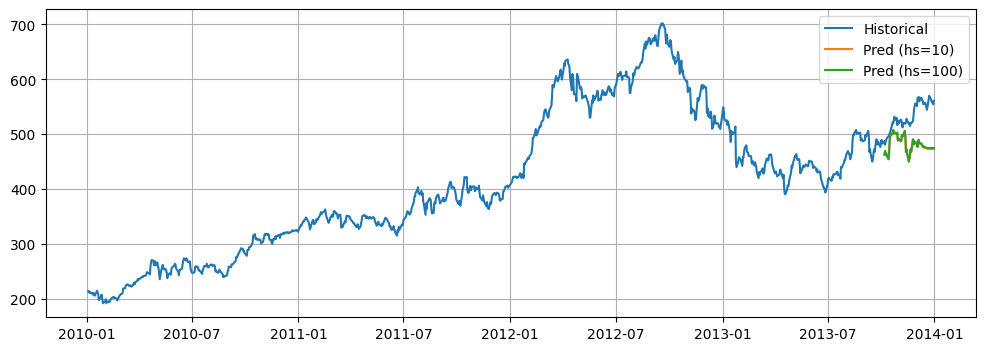

In [135]:
# device already defined above
# torch.manual_seed(999)  # keep seed once

def train_model(model, chaky_data, epochs=100, lr=1e-3, device=device):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for i in range(epochs):
        for seq, y_train in chaky_data:
            seq = seq.to(device)
            y_train = y_train.to(device)

            y_pred = model(seq)
            loss = criterion(y_pred, y_train)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if i % 10 == 0:
            print(f'Epoch: {i:2} Loss: {loss.item():10.8f}')
    return model

def predict_steps(model, preds, ws, n=15, device=device):
    model.eval()
    with torch.no_grad():
        for _ in range(n):
            seq = torch.FloatTensor(preds[-ws:]).to(device)
            yhat = model(seq)
            preds.append(yhat.item())
    return preds

# --- Small model (hs=10)
small = NABIN_RNN(input_s=1, hs=10, output_size=1)
count_parameters(small)
small = train_model(small, chaky_data, epochs=100, device=device)
preds_small = train_set_norm[-ws:].tolist()
preds_small = predict_steps(small, preds_small, ws, n=15, device=device)
small_true = scaler.inverse_transform(np.array(preds_small[-ws:]).reshape(-1,1)).ravel()

# --- Large model (hs=100)
large = NABIN_RNN(input_s=1, hs=100, output_size=1)
count_parameters(large)
large = train_model(large, chaky_data, epochs=100, device=device)
preds_large = train_set_norm[-ws:].tolist()
preds_large = predict_steps(large, preds_large, ws, n=15, device=device)
large_true = scaler.inverse_transform(np.array(preds_large[-ws:]).reshape(-1,1)).ravel()

# --- Plot both on same axes
x = df['Close'][-ws:].index
plt.figure(figsize=(12,4)); plt.grid(True)
plt.plot(df['Close'], label='Historical')
plt.plot(x, small_true, label='Pred (hs=10)')
plt.plot(x, large_true, label='Pred (hs=100)')
plt.legend()
plt.show()


In [136]:
# --- Comparison Summary ---
print("\n=== Comparison Summary ===")
print(f"Small LSTM (hs={small_hs}) -> params: {small_params:,} | final training loss: {small_loss:.6f}")
print(f"Large LSTM (hs={large_hs}) -> params: {large_params:,} | final training loss: {large_loss:.6f}")
print("\nDoes bigger always mean better?")
print("- Larger hidden size may reduce training loss but can overfit and slow training.")
print("- Smaller hidden size generalizes better on limited data but may underfit.")
print("Trade-offs: accuracy vs. overfitting, training time, and memory usage.")


=== Comparison Summary ===
Small LSTM (hs=10) -> params: 531 | final training loss: 0.000001
Large LSTM (hs=100) -> params: 41,301 | final training loss: 0.000002

Does bigger always mean better?
- Larger hidden size may reduce training loss but can overfit and slow training.
- Smaller hidden size generalizes better on limited data but may underfit.
Trade-offs: accuracy vs. overfitting, training time, and memory usage.
